# Import Data

In [1]:
import pandas as pd
# import utils as uti
from utils import results as res
import matplotlib.pyplot as plt
import pickle

In [2]:
df_train = pd.read_pickle("../data/train_df.pkl")
df_test = pd.read_pickle("../data/test_df.pkl")
walds = pd.read_pickle("../data/walds.pkl")

In [3]:
with open("../data/models.pkl", "rb") as file:
    models = pickle.load(file)

In [4]:
walds.head()

,var,wald,corr,corr ind
0,V14,1455.634827,-0.098727,False
1,V4,1297.380483,-0.106859,False
2,V10,1183.148737,-0.100605,False
3,V2,1163.591804,-0.535577,True
4,V3,1134.292483,-0.417851,True


In [5]:
models

{'logi': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x7f150c124d70>,
 'xgb': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.8447411578889518, device=None,
               early_stopping_rounds=None, enable_categorical=True,
               eval_metric='auc', feature_types=None, feature_weights=None,
               gamma=1.3949386065204183, grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.034646653174710614,
               max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=4, max_leaves=None,
               min_child_weight=3.6473162849112093, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=-1, num_parallel_tree=None, ...),
 'rf': RandomForestClassifier(class_weight='balanced_subsample', 

# Make Training and Test Predictions

## Logistic

In [6]:
import statsmodels.api as sm

In [7]:
models['logi'].params.index.tolist()[1:]

['V14', 'V4', 'V12', 'V13']

In [8]:
tmp = sm.add_constant(
    df_train[models['logi'].params.index.tolist()[1:]],
    has_constant="add"
)

df_train['logi'] = models['logi'].predict(tmp)

In [9]:
tmp = sm.add_constant(
    df_test[models['logi'].params.index.tolist()[1:]],
    has_constant="add"
)

df_test['logi'] = models['logi'].predict(tmp)

## Logistic w Polynomials

In [10]:
models['logi_poly'].params.index.tolist()[1:]

['V14',
 'V14_2',
 'V14_3',
 'V14_4',
 'V4',
 'V4_2',
 'V4_3',
 'V4_4',
 'V12',
 'V12_2',
 'V12_3',
 'V12_4',
 'V13',
 'V13_2',
 'V13_3',
 'V13_4']

Create the polynomial inputs we need for this model.

In [11]:
for i in models['logi'].params.index.tolist()[1:]:
    # alt_feat.append(i)
    
    for j in list(range(2,5)):
    
        # alt_feat.append(f'{i}_{j}')
        df_train[f'{i}_{j}'] = df_train[f'{i}'] ** j 
        df_test[f'{i}_{j}'] = df_test[f'{i}'] ** j 

In [12]:
tmp = sm.add_constant(
    df_train[models['logi_poly'].params.index.tolist()[1:]],
    has_constant="add"
)

df_train['logi_poly'] = models['logi_poly'].predict(tmp)

In [13]:
tmp = sm.add_constant(
    df_test[models['logi_poly'].params.index.tolist()[1:]],
    has_constant="add"
)

df_test['logi_poly'] = models['logi_poly'].predict(tmp)

## XGB

In [14]:
df_train['xgb'] = models['xgb'].predict_proba(df_train[models['xgb'].get_booster().feature_names])[:, 1]

In [15]:
df_test['xgb'] = models['xgb'].predict_proba(df_test[models['xgb'].get_booster().feature_names])[:, 1]

## Random Forest

In [16]:
df_train['rf'] = models['rf'].predict_proba(df_train[models['rf'].feature_names_in_.tolist()])[:, 1]

In [17]:
df_test['rf'] = models['rf'].predict_proba(df_test[models['rf'].feature_names_in_.tolist()])[:, 1]

## Perfect prediction

In [18]:
df_train.sort_values(by='Class', inplace= True)
df_train['perf'] = range(len(df_train))

In [19]:
df_test.sort_values(by='Class', inplace=True)
df_test['perf'] = range(len(df_test))

# Compare Performance

In [20]:
df_train.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V12_2,V12_3,V12_4,V13_2,V13_3,V13_4,logi_poly,xgb,rf,perf
109011,71174.0,-2.108259,1.173406,1.614294,0.482867,0.067209,-0.191013,0.191246,-1.705859,-0.177615,...,0.022136,-0.003293,0.000490,0.490385,-0.343405,0.240478,1.648280e-04,0.000446,0.0,0
133535,80429.0,-0.855705,-0.148187,2.545324,-0.936748,-0.521145,-0.067124,0.495980,0.044905,0.828457,...,0.011796,0.001281,0.000139,0.599222,-0.463855,0.359067,9.013310e-06,0.000084,0.0,1
105849,69717.0,-1.106737,0.668748,1.341003,0.933475,0.376444,-0.128874,0.271983,0.221286,-0.439344,...,0.256391,-0.129824,0.065736,4.699456,-10.187590,22.084891,2.698381e-04,0.000267,0.0,2
230195,146231.0,1.745974,-0.603811,-0.449013,1.240330,-0.619052,-0.056696,-0.547876,0.157395,0.877337,...,0.003625,0.000218,0.000013,1.820695,-2.456720,3.314930,3.091604e-04,0.000166,0.0,3
193065,129979.0,1.824455,-1.130767,-0.624745,-1.482597,-0.870230,-0.340117,-0.650900,-0.073264,2.230565,...,1.782386,2.379593,3.176900,2.326529,3.548647,5.412738,9.760300e-08,0.000089,0.0,4


In [21]:
df_test.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V12_2,V12_3,V12_4,V13_2,V13_3,V13_4,logi_poly,xgb,rf,perf
62125,50139.0,1.157527,-1.667179,0.873225,-0.842167,-1.950670,-0.035952,-1.183210,0.016793,-1.105799,...,0.002834,-0.000151,0.000008,0.459622,0.311603,0.211252,1.292049e-05,0.000151,0.0,0
131964,79804.0,1.197725,0.346987,0.441015,0.905296,-0.094776,-0.354856,0.075393,-0.061984,-0.340156,...,1.877192,2.571953,3.523850,0.987706,0.981616,0.975563,5.246788e-05,0.000140,0.0,1
165036,117156.0,1.934841,-1.121273,-0.352190,-0.079542,-1.331119,-0.575178,-0.838136,-0.138740,0.328853,...,0.117185,0.040115,0.013732,0.499005,0.352499,0.249006,4.446266e-05,0.000093,0.0,2
271756,164725.0,2.102373,-0.279266,-1.644408,0.286656,0.394249,-0.195728,0.002842,-0.153651,0.922407,...,0.006864,-0.000569,0.000047,0.102061,-0.032605,0.010416,1.194304e-04,0.000086,0.0,3
194748,130741.0,-0.913360,-0.141398,-0.425748,-3.290592,1.759517,3.655667,-0.931296,1.530835,-0.963198,...,0.480587,-0.333164,0.230964,0.003256,-0.000186,0.000011,2.516583e-13,0.000101,0.0,4


In [22]:
models_names = {
    "Logistic regression": "logi",
    "Logistic Poly regression": "logi_poly",
    "XGBoost": "xgb",
    "Random Forest": "rf",
    "Perfect": "perf"    
}

## PR-ROC

This is the more meaningful metric evaluated given it considers the rareness of events. From it we see that XGB performs the best out of sample and reasonably well in sample. Random Forest performs best in certain ranges but that is not consistent in the test sample. This is likely not overfitting from the number of trials since there were not that many, but rather the number of parameters adding too much complexity. 

Worth noting, the logistic regression model with polynomials performs better than base logistic, indicating it captures some of the non linear relationships observed during estimation. Its performance is not the best but its consistent over samples.

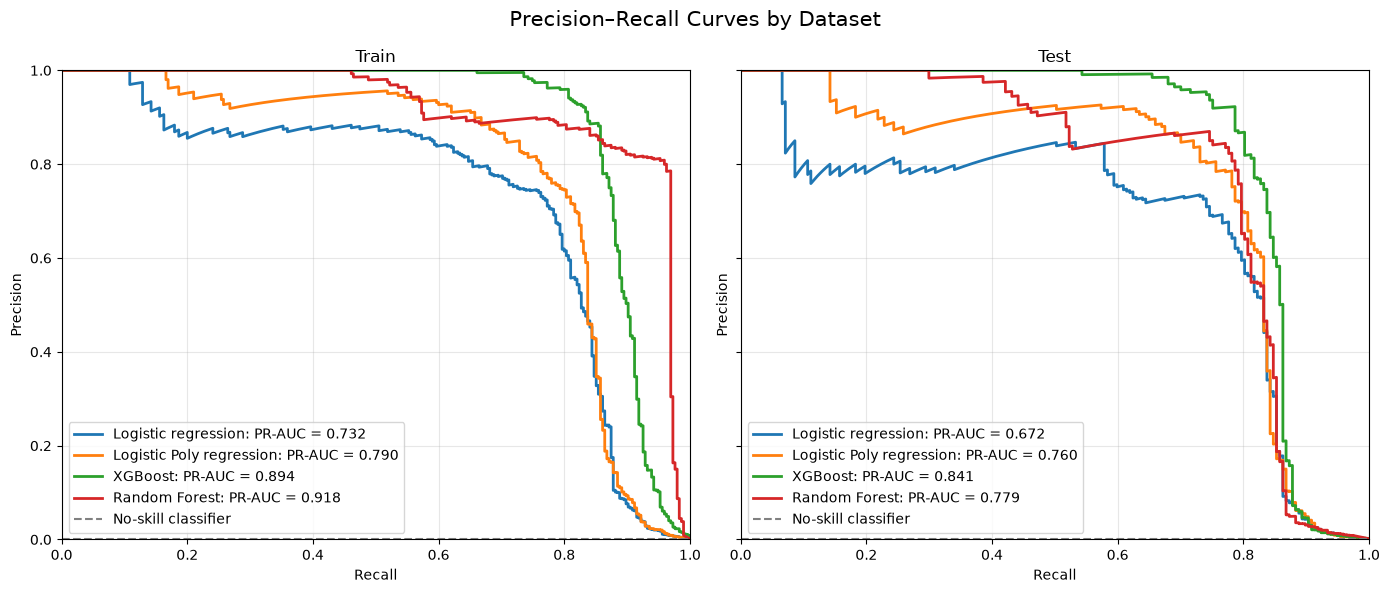

In [23]:
# res.roc_plot(
#     df_1=df_train,
#     df_2=df_test,
#     models=dict(list(models_names.items())[:-1]),
#     target_name="Class"
# )

res.pr_auc_plot(
    df_1=df_train,
    df_2=df_test,
    models=dict(list(models_names.items())[:-1]),
    target_name="Class"
)

## Lift

These type of plots are common for classification problems. However, given the rareness of events they are not very helpful. However, it does show that logistic and logistic poly are the most consistent over the samples, while ML approaches push less to lower predictions out of sample. Normally, this would indicate more time could be spent reducing overfitting. However, we already know test and training samples are inherently different regardless of sampling.

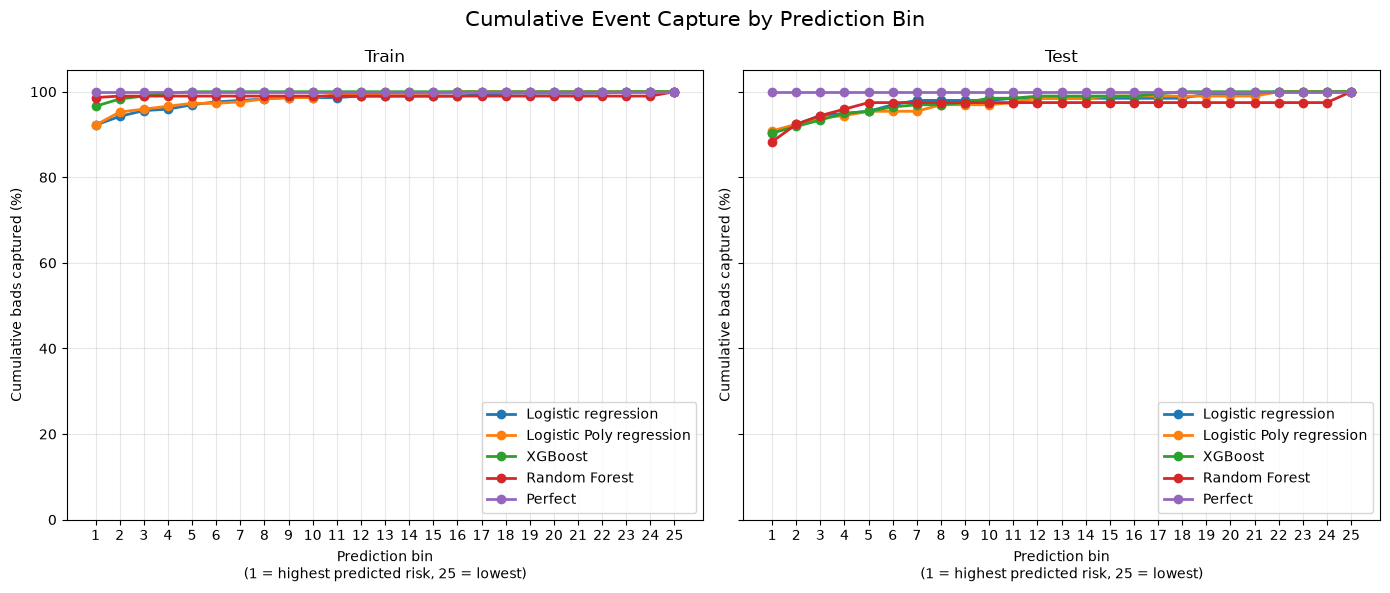

In [24]:
res.cumulative_event_rate_plot(
    df_1=df_train,
    df_2=df_test,
    models=models_names,
    target_name="Class",
    n_bins=25
)

## KS

This is also a common metric used for classification. The main takeaway is that logistic and logistic poly models remain the most consistent over samples. Random Forest KS happens in 2nd lowest bin for test data, which we expect given performance in PR-AUC.

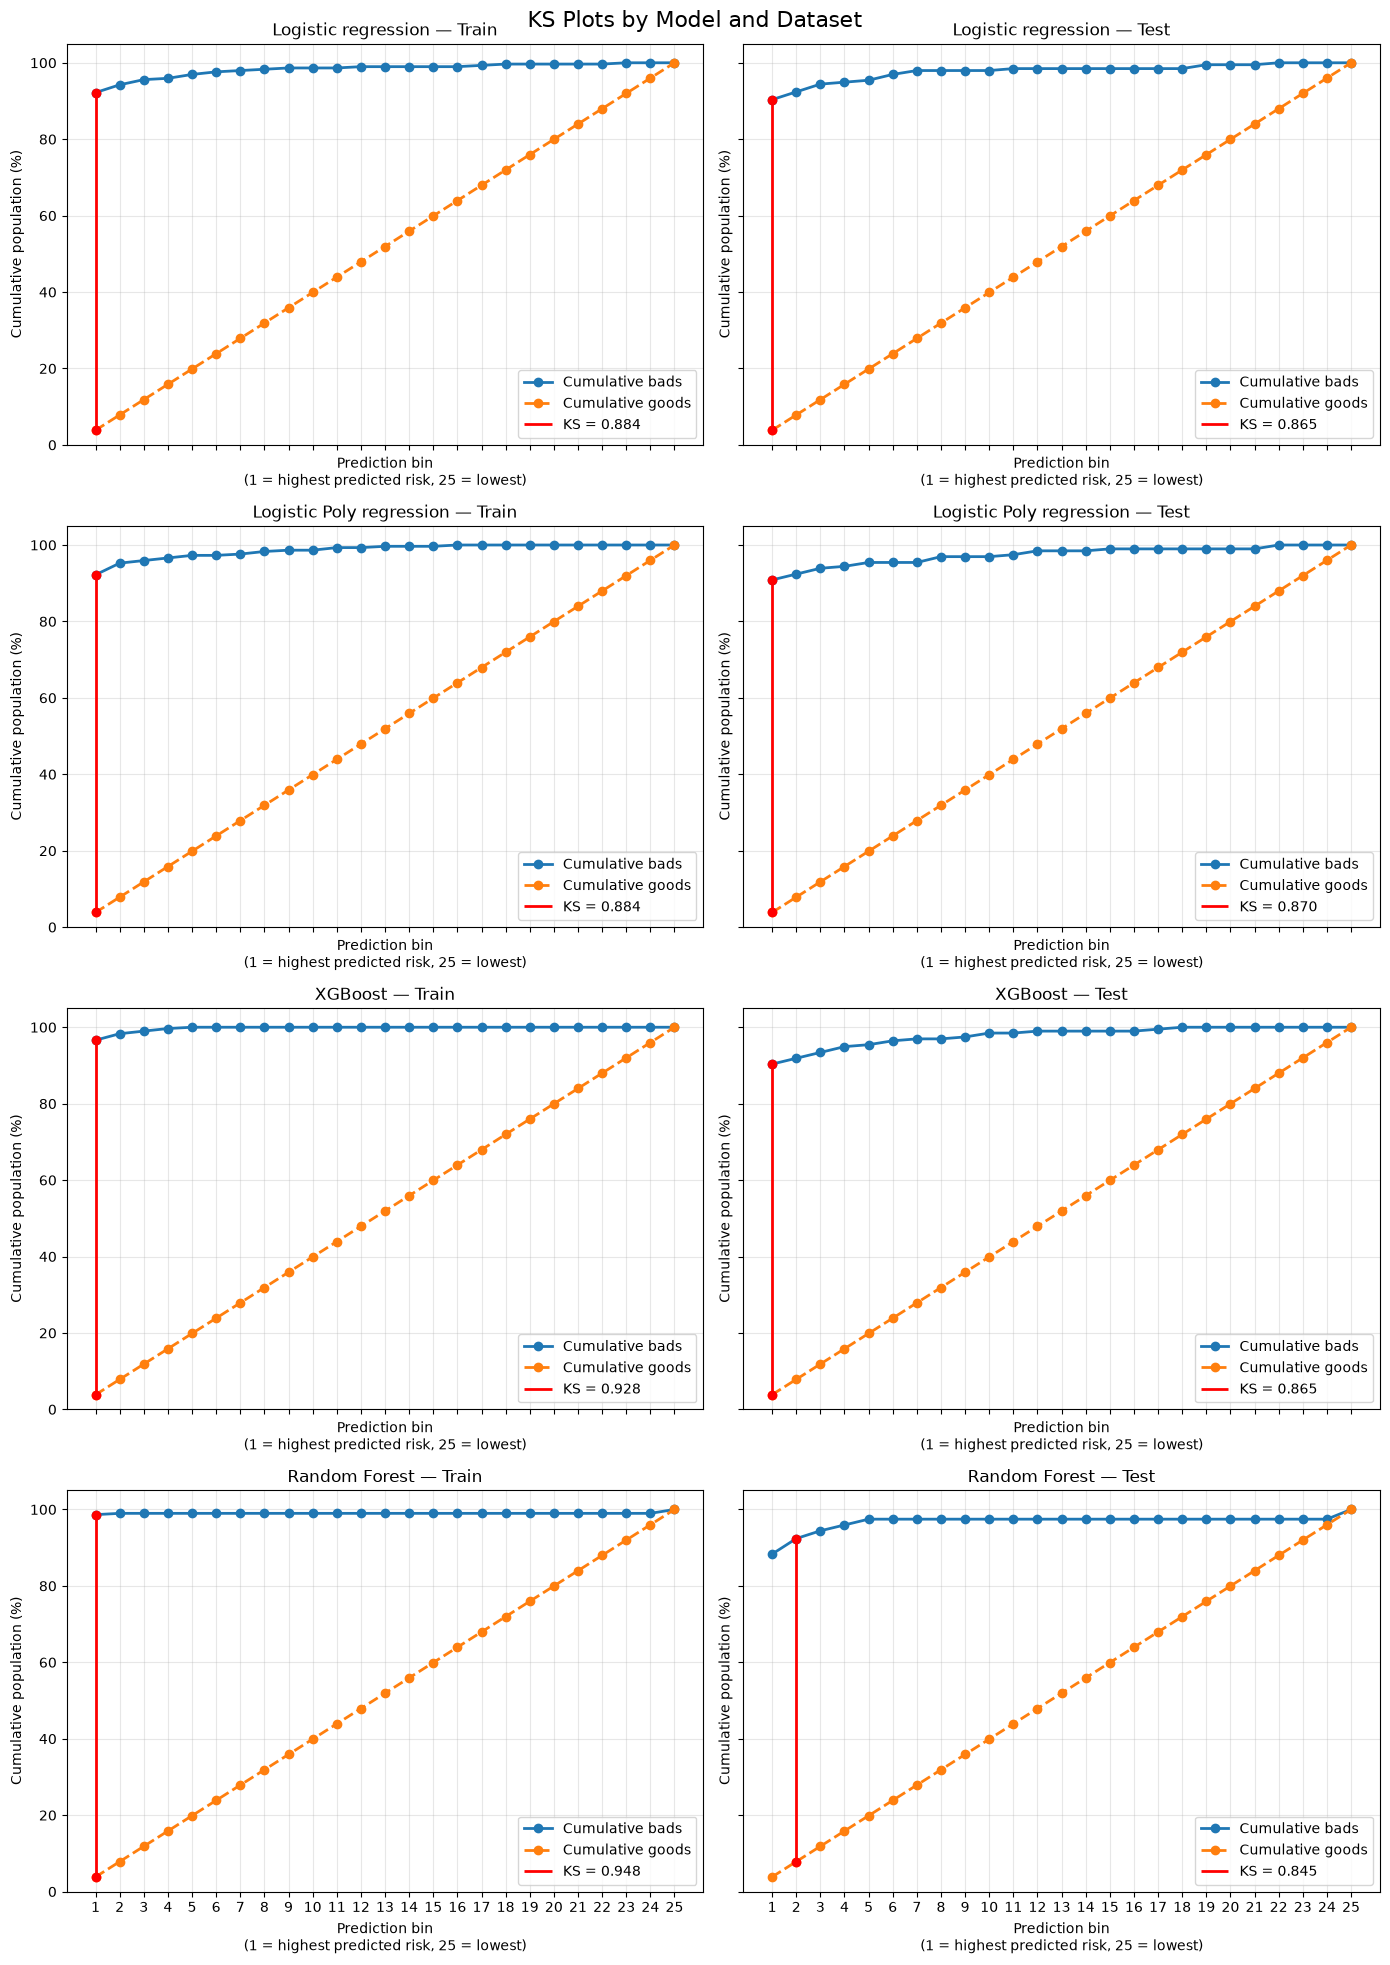

In [25]:
res.ks_plot(
    df_1=df_train,
    df_2=df_test,
    models=dict(list(models_names.items())[:-1]),
    target_name="Class",
    n_bins=25
)

# Calibration

These plots are useful in evaluating the interpretability of predictions. Specifically, if we can treat them as probabilities. This is done by comparing predicted probabilities to observed events. The plot shows all models except RF would have reasonable interpretations are probabilities. RF model needs more work to resolve overfitting given the sampling limitations and possibly scale output to have interpretable probabilities.

However, all models still show ability to rank order, which is not impacted by the interpretability of output as a probability.

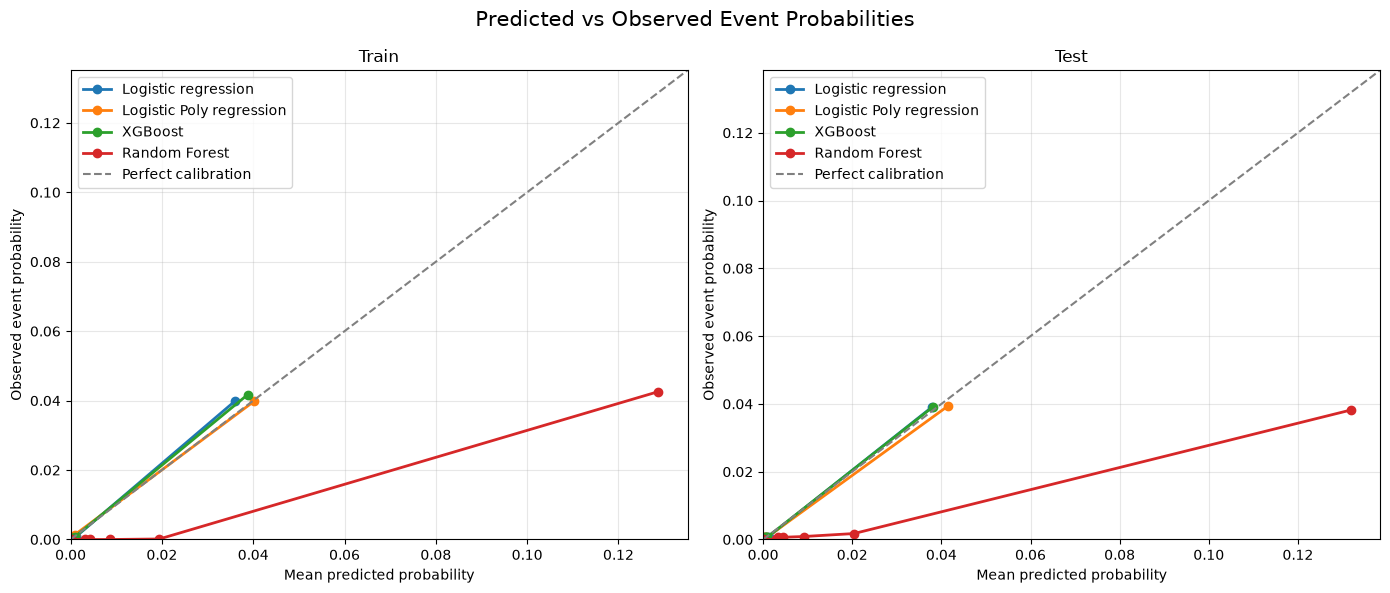

In [26]:
res.calibration_plot(
    df_1=df_train,
    df_2=df_test,
    models=dict(list(models_names.items())[:-1]),
    target_name="Class",
    n_bins=25
)

# Save Predictions

In [27]:
df_train['sample'] = 'train'
df_test['sample'] = 'test'

In [28]:
results = pd.concat(
    [df_train, df_test],
    ignore_index=True
)

In [29]:
results.to_pickle("../data/results_df.pkl")